In [1]:
!pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 103.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 814.0/814.0 kB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: dacite
    F

In [2]:
import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import mlflow
import mlflow.tensorflow

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

2026-03-07 03:54:42.364317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772855682.545151      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772855682.596645      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772855683.018123      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772855683.018161      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772855683.018163      55 computation_placer.cc:177] computation placer alr

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("dagshub_token")

In [4]:
DAGSHUB_USERNAME = "Aryanupadhyay23"
DAGSHUB_REPO = "Emotion-Detection-Deep-Learning"

MLFLOW_TRACKING_URI = f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = secret_value_0

In [5]:
mlflow.set_experiment("RAF_DB_EfficientNetV2S")

mlflow.start_run(run_name="efficientnetv2s_class_weights")

mlflow.set_tags({
    "project":"Emotion-Detection-Deep-Learning",
    "github_user":"Aryanupadhyay23",
    "model":"EfficientNetV2S",
    "training_strategy":"class_weights",
    "framework":"TensorFlow"
})

In [6]:
OUTPUT_DIR = "/kaggle/working/output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/output


In [7]:
DATASET_PATH = "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET"

TRAIN_DIR = os.path.join(DATASET_PATH,"train")
TEST_DIR  = os.path.join(DATASET_PATH,"test")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

EMOTIONS = ['Surprise','Fear','Disgust','Happy','Sad','Anger','Neutral']
NUM_CLASSES = len(EMOTIONS)

mlflow.log_params({
    "model_name":"EfficientNetV2S",
    "training_strategy":"class_weights",
    "image_size":IMG_SIZE,
    "batch_size":BATCH_SIZE,
    "epochs":EPOCHS,
    "num_classes":NUM_CLASSES
})

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="categorical",
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 12271 files belonging to 7 classes.


I0000 00:00:1772855725.581756      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 3068 files belonging to 7 classes.


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [10]:
data_aug = keras.Sequential([

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),

])

train_ds = train_ds.map(
    lambda x,y:(data_aug(x),y),
    num_parallel_calls=AUTOTUNE
)

In [11]:
labels = []

for _,y in train_ds.unbatch():
    labels.append(np.argmax(y.numpy()))

labels = np.array(labels)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(weights))

mlflow.log_param("class_weights", str(class_weights))

'{0: np.float64(1.3589147286821706), 1: np.float64(6.238434163701068), 2: np.float64(2.4449093444909344), 3: np.float64(0.3673512154233026), 4: np.float64(0.884460141271443), 5: np.float64(2.4865248226950354), 6: np.float64(0.6945324881141046)}'

In [12]:
base_model = keras.applications.EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_preprocessing=False
)

base_model.trainable = True

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [13]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = keras.ops.cast(inputs, "float32")
x = (x / 128.0) - 1.0

x = base_model(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation="swish")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast (Cast)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,995,943 (80.09 MB)

 Trainable params: 20,839,511 (79.50 MB)

 Non-trainable params: 156,432 (611.06 KB)

In [14]:
tf.keras.utils.plot_model(
    model,
    to_file=os.path.join(OUTPUT_DIR,"architecture.png"),
    show_shapes=True
)

mlflow.log_artifact(os.path.join(OUTPUT_DIR,"architecture.png"))

In [15]:
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=10000
)

optimizer = keras.optimizers.Adam(lr_schedule)

In [16]:
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
optimizer=optimizer,
loss=loss_fn,
metrics=["accuracy"]
)

mlflow.log_params({
    "optimizer":"Adam",
    "lr_schedule":"CosineDecay",
    "label_smoothing":0.1
})

In [17]:
callbacks = [

keras.callbacks.ModelCheckpoint(
os.path.join(OUTPUT_DIR,"best_model.keras"),
monitor="val_accuracy",
save_best_only=True,
verbose=1
),

keras.callbacks.EarlyStopping(
monitor="val_accuracy",
patience=10,
restore_best_weights=True
),

keras.callbacks.CSVLogger(
os.path.join(OUTPUT_DIR,"training_log.csv")
)
]

In [18]:
start = time.time()

history = model.fit(
train_ds,
validation_data=test_ds,
epochs=EPOCHS,
callbacks=callbacks,
class_weight=class_weights
)

training_time = time.time() - start

mlflow.log_metric("training_time_seconds", training_time)

Epoch 1/100


I0000 00:00:1772855879.076372     150 service.cc:152] XLA service 0x7f9b6c01a530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772855879.076425     150 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772855891.823366     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-07 03:58:29.368105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:58:29.559415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 03:58:30.031615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

383/384 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.2396 - loss: 2.3095

2026-03-07 04:01:04.768139: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 04:01:04.954755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 04:01:05.352764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 04:01:05.548688: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-07 04:01:06.072906: E external/local_xla/xla/stream_

384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.2398 - loss: 2.3089
Epoch 1: val_accuracy improved from -inf to 0.50554, saving model to /kaggle/working/output/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 334s 499ms/step - accuracy: 0.2399 - loss: 2.3084 - val_accuracy: 0.5055 - val_loss: 1.5008
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.4594 - loss: 1.6057
Epoch 2: val_accuracy improved from 0.50554 to 0.60593, saving model to /kaggle/working/output/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 92s 237ms/step - accuracy: 0.4595 - loss: 1.6055 - val_accuracy: 0.6059 - val_loss: 1.3197
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.5811 - loss: 1.2969
Epoch 3: val_accuracy improved from 0.60593 to 0.67699, saving model to /kaggle/working/output/best_model.keras
384/384 ━━━━━━━━━━━━━━━━━━━━ 92s 238ms/step - accuracy: 0.5811 - loss: 1.2968 - val_accuracy: 0.6770 - val_loss: 1.1896
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/s

In [19]:
for i in range(len(history.history["accuracy"])):

    mlflow.log_metric("train_accuracy",history.history["accuracy"][i],step=i)
    mlflow.log_metric("val_accuracy",history.history["val_accuracy"][i],step=i)
    mlflow.log_metric("train_loss",history.history["loss"][i],step=i)
    mlflow.log_metric("val_loss",history.history["val_loss"][i],step=i)

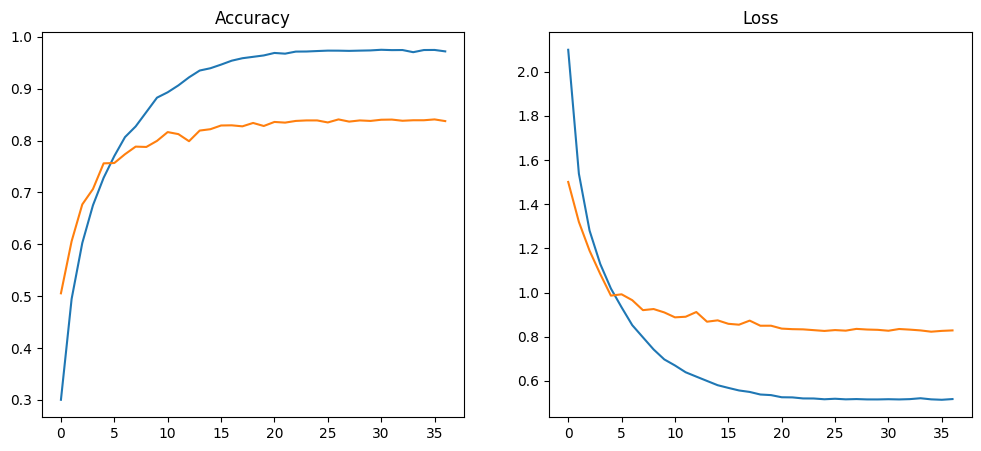

In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")

curve_path=os.path.join(OUTPUT_DIR,"training_curves.png")

plt.savefig(curve_path)

mlflow.log_artifact(curve_path)

plt.show()

In [21]:
best_model = keras.models.load_model(
os.path.join(OUTPUT_DIR,"best_model.keras")
)

mlflow.tensorflow.log_model(best_model,"model")

2026/03/07 04:58:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/07 04:58:50 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [22]:
y_true=[]
y_pred=[]
y_prob=[]

for x,y in test_ds:

    preds = best_model.predict(x)

    y_true.extend(np.argmax(y.numpy(),axis=1))
    y_pred.extend(np.argmax(preds,axis=1))
    y_prob.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━

In [23]:
accuracy = accuracy_score(y_true,y_pred)

print("Test Accuracy:",accuracy)

mlflow.log_metric("test_accuracy",accuracy)

Test Accuracy: 0.8409387222946545


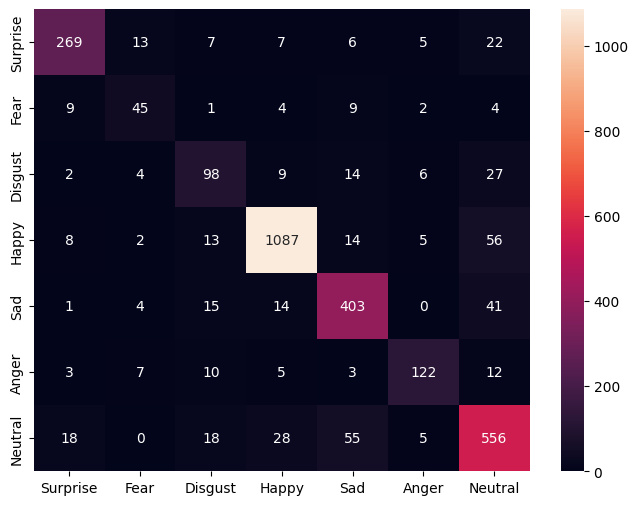

In [24]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,annot=True,fmt="d",
xticklabels=EMOTIONS,
yticklabels=EMOTIONS)

cm_path=os.path.join(OUTPUT_DIR,"confusion_matrix.png")

plt.savefig(cm_path)

mlflow.log_artifact(cm_path)

plt.show()

In [25]:
report = classification_report(y_true,y_pred,target_names=EMOTIONS)

print(report)

report_path=os.path.join(OUTPUT_DIR,"classification_report.txt")

with open(report_path,"w") as f:
    f.write(report)

mlflow.log_artifact(report_path)

              precision    recall  f1-score   support

    Surprise       0.87      0.82      0.84       329
        Fear       0.60      0.61      0.60        74
     Disgust       0.60      0.61      0.61       160
       Happy       0.94      0.92      0.93      1185
         Sad       0.80      0.84      0.82       478
       Anger       0.84      0.75      0.79       162
     Neutral       0.77      0.82      0.80       680

    accuracy                           0.84      3068
   macro avg       0.78      0.77      0.77      3068
weighted avg       0.84      0.84      0.84      3068



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


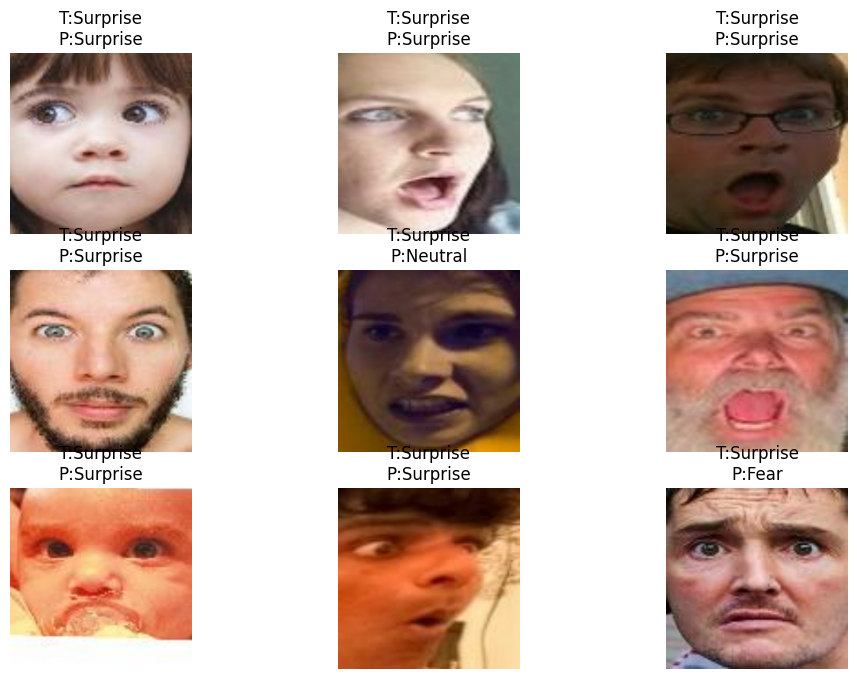

In [26]:
plt.figure(figsize=(12,8))

for images,labels in test_ds.take(1):

    preds = best_model.predict(images)

    for i in range(9):

        plt.subplot(3,3,i+1)

        img = images[i].numpy().astype("uint8")

        true = EMOTIONS[np.argmax(labels[i])]
        pred = EMOTIONS[np.argmax(preds[i])]

        plt.imshow(img)

        plt.title(f"T:{true}\nP:{pred}")

        plt.axis("off")

pred_path=os.path.join(OUTPUT_DIR,"prediction_examples.png")

plt.savefig(pred_path)

mlflow.log_artifact(pred_path)

plt.show()

In [27]:
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
y_prob = np.array(y_prob)

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr, tpr)

    mlflow.log_metric(f"roc_auc_{EMOTIONS[i]}", roc_auc)

In [28]:
mlflow.end_run()

🏃 View run efficientnetv2s_class_weights at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/13/runs/248f2b6a9c934a3dbcdde842c683077b
🧪 View experiment at: https://dagshub.com/Aryanupadhyay23/Emotion-Detection-Deep-Learning.mlflow/#/experiments/13
